In [ ]:
!pip install ruamel.yaml
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn azureml-sdk openai

  Using cached azureml_sdk-1.62.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached azureml_core-1.61.0.post3-py3-none-any.whl.metadata (3.5 kB)
  Using cached azureml_dataset_runtime-1.62.0-py3-none-any.whl.metadata (1.4 kB)
  Using cached azureml_train_core-1.62.0-py3-none-any.whl.metadata (2.0 kB)
INFO: pip is looking at multiple versions of azureml-sdk to determine which version is compatible with other requirements. This could take a while.
  Using cached azureml_sdk-1.61.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached azureml_dataset_runtime-1.61.0-py3-none-any.whl.metadata (1.4 kB)
  Using cached azureml_train_core-1.61.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached azureml_sdk-1.60.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached azureml_core-1.60.0.post1-py3-none-any.whl.metadata (3.4 kB)
  Using cached azureml_dataset_runtime-1.60.0-py3-none-any.whl.metadata (1.4 kB)
  Using cached azureml_train_core-1.60.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached azureml

**EXPLORATORY DASAR & PEMBERSIHAN DATA**

In [32]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PS_20174392719_1491204439457_log.csv"

# Load dataset
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ealaxi/paysim1",
  file_path,
)

# Mengambil semua data fraud yang ada di dataset
df_fraud_all = df[df['isFraud'] == 1]

# Ambil 500k sampel untuk kecepatan
df_normal_sample = df[df['isFraud'] == 0].sample(n=500000, random_state=42)

# Menggambungkan df_fraud_all & normal_sample
df_combined = pd.concat([df_fraud_all, df_normal_sample])

print("Dataset berhasil dimuat!")
print("Jumlah baris & kolom:", df_combined.shape)
print(df_combined.head())

/tmp/ipykernel_13342/12415730.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'paysim1' dataset.
Dataset berhasil dimuat!
Jumlah baris & kolom: (508213, 11)
     step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
2       1  TRANSFER    181.0  C1305486145          181.0             0.0   
3       1  CASH_OUT    181.0   C840083671          181.0             0.0   
251     1  TRANSFER   2806.0  C1420196421         2806.0             0.0   
252     1  CASH_OUT   2806.0  C2101527076         2806.0             0.0   
680     1  TRANSFER  20128.0   C137533655        20128.0             0.0   

        nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
2     C553264065             0.0             0.0        1               0  
3      C38997010         21182.0             0.0        1               0  
251   C972765878             0.0             0.0        1               0  
252  C1007251739         26202.0             0.0        1               0  
680  C1848415041             0.0         

In [33]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 508213 entries, 2 to 4638027
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            508213 non-null  int64  
 1   type            508213 non-null  object 
 2   amount          508213 non-null  float64
 3   nameOrig        508213 non-null  object 
 4   oldbalanceOrg   508213 non-null  float64
 5   newbalanceOrig  508213 non-null  float64
 6   nameDest        508213 non-null  object 
 7   oldbalanceDest  508213 non-null  float64
 8   newbalanceDest  508213 non-null  float64
 9   isFraud         508213 non-null  int64  
 10  isFlaggedFraud  508213 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 46.5+ MB


In [34]:
print('\nDistribusi Kelas (isFraud):')
print(df['isFraud'].value_counts())


Distribusi Kelas (isFraud):
isFraud
0    6354407
1       8213
Name: count, dtype: int64


### **2. EDA - Pattern Shift Analysis**

#### **2.1 Exploratory dasar & Pembersihan data**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Melakukan cek distribusi berdasarkan tipe Transaksi

Distribusi Tipe Transaksi:
type
CASH_OUT    180062
PAYMENT     169050
CASH_IN     110093
TRANSFER     45776
DEBIT         3232
Name: count, dtype: int64


/tmp/ipykernel_13342/3207736748.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette='viridis')


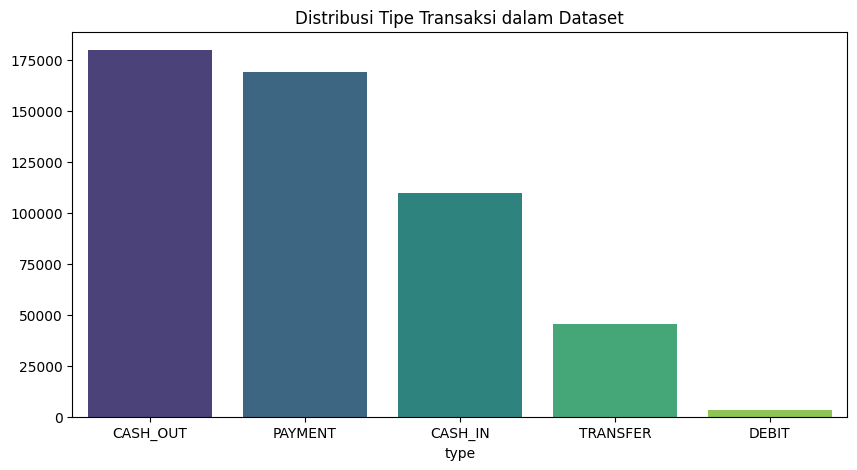

In [35]:
print("Distribusi Tipe Transaksi:")
type_counts = df_combined['type'].value_counts()
print(type_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, palette='viridis')
plt.title('Distribusi Tipe Transaksi dalam Dataset')
plt.show()

Melakukan cek proporsi pada 'Fraud'

*   Menambahkan kondisi jika tingkat penipuan (fraud_rate) < 1: Menggunakan **metrik utama PR-AUC**



*   Alasan: PR-AUC (Precission -Recall Are Under the Curve) memberikan penilaian yang lebih robust pada kelas minoritas (fraud) dan mencegah interpretasi bias dari metrik Akurasi atau ROC-AUC pada data jomplang.




In [36]:
fraud_count = df_combined['isFraud'].value_counts()
fraud_rate = (fraud_count[1] / len(df)) * 100

print(f"Jumlah Fraud: {fraud_count[1]} ({fraud_rate:.4f}%)")
print(f"Jumlah Non-Fraud: {fraud_count[0]}")

# Pemilihan Metrik
if fraud_rate < 1:
    print("\n[JUSTIFIKASI TEKNIS: Pemilihan Metrik]")
    print(f"Data bersifat Highly Imbalanced (Rasio 1:{int(fraud_count[0]/fraud_count[1])})")
    print("Justifikasi: Metrik PR-AUC (Precision-Recall Curve) sebagai metrik utama")

Jumlah Fraud: 8213 (0.1291%)
Jumlah Non-Fraud: 500000

[JUSTIFIKASI TEKNIS: Pemilihan Metrik]
Data bersifat Highly Imbalanced (Rasio 1:60)
Justifikasi: Metrik PR-AUC (Precision-Recall Curve) sebagai metrik utama


In [37]:
# Cek Missing Values
print("Missing Values per Kolom:")
print(df_combined.isnull().sum())

Missing Values per Kolom:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Statistik deskriptif kolom 'amount' (jumlah transaksi)


Statistik Deskriptif Amount:
count    5.082130e+05
mean     1.995301e+05
std      6.803494e+05
min      0.000000e+00
25%      1.376018e+04
50%      7.744718e+04
75%      2.134633e+05
max      6.988673e+07
Name: amount, dtype: float64


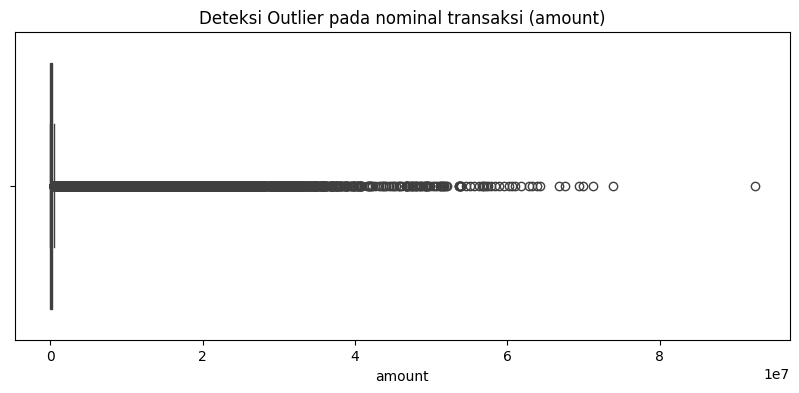

In [38]:
# Melihat statistik deskriptif untuk memantau outlier pada 'amount'
print("\nStatistik Deskriptif Amount:")
print(df_combined['amount'].describe())

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['amount'])
plt.title('Deteksi Outlier pada nominal transaksi (amount)')
plt.show()

Filter data pada tipe transaksi relevab ('TRANSFER' & 'CASH_OUT')


*   TRANSFER: Biaya yang dikirim ke akun lain
*   CASH_OUTL Biaya yang ditarik dari sebuah akun



In [39]:
# Filter data pada tipe transaksi relevan

df_filtered = df_combined[df_combined['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

print(f"Total data sekarang: {df_filtered.shape[0]}")
print(f"Total Fraud yang diamankan: {df_filtered['isFraud'].sum()}")

Total data sekarang: 225838
Total Fraud yang diamankan: 8213


#### **2.2 Temporal Pattern Analysis**

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Konversi 'Step' ke Jam dan Hari
df_filtered['hour'] = df_filtered['step'] % 24
df_filtered['day'] = df_filtered['step'] // 24

Visualisasi Distribusi Jam (Normal & Fraud)

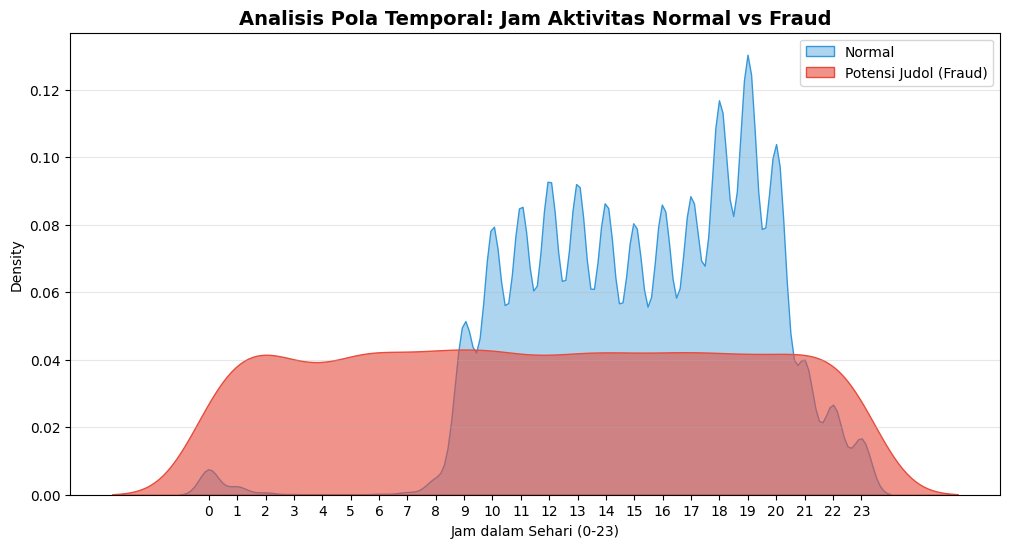

In [41]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df_filtered[df_filtered['isFraud'] == 0]['hour'],
            label='Normal', fill=True, color='#3498db', alpha=0.4)
sns.kdeplot(df_filtered[df_filtered['isFraud'] == 1]['hour'],
            label='Potensi Judol (Fraud)', fill=True, color='#e74c3c', alpha=0.6)

plt.title('Analisis Pola Temporal: Jam Aktivitas Normal vs Fraud', fontsize=14, fontweight='bold')
plt.xlabel('Jam dalam Sehari (0-23)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Berdasarkan hasil grafik, **pola "rata" adalah anomali perilaku** karena mengabaikan siklus biologis manusia. Saat nasabah normal beristirahat (00:00–07:00), aktivitas fraud tetap persisten. <br>
Kemerataan ini membuktikan pola tersebut bersifat sistematis atau adiktif, bukan kebutuhan transaksi harian alami.

**Mencari titik "Early Warning"**

In [42]:
fraud_acc_list = df_filtered[df_filtered['isFraud'] == 1]['nameOrig'].unique()
print(f"Jumlah Akun Fraud yang diamankan: {len(fraud_acc_list)}")

# Ambil semua transaksi dari akun mencurigakan dari Dataframe lengkap
df_fraud_history = df[df['nameOrig'].isin(fraud_acc_list)].copy()

Menghitung rata-rata data sebelum terdeteksi 'fraud'

In [47]:
# Mencari 'step' (langkah / tindakan) pertama saat fraud terdeteksi/akun di df_fraud_history
first_fraud_step = df_fraud_history[df_fraud_history['isFraud'] == 1].groupby('nameOrig')['step'].min().reset_index()
first_fraud_step.columns = ['nameOrig', 'first_fraud_at']

# Memastikan kolom 'first_fraud_at' ditambahkan secara eksplisit ke df_fraud_history
df_fraud_history = pd.merge(df_fraud_history, first_fraud_step, on='nameOrig', how='left')

# Hitung berapa jam sebelum fraud terjadi (first_fraud_at - step)
df_fraud_history['hours_before_fraud'] = df_fraud_history['first_fraud_at'] - df_fraud_history['step']

# Filter hanya transaksi yg terjadi sebelum deteksi fraud & bukan transaksi fraud itu sendiri
df_pre_fraud_activity = df_fraud_history[df_fraud_history['hours_before_fraud'] > 0]

mean_hours_before_fraud = df_pre_fraud_activity['hours_before_fraud'].mean()
mean_days_before_fraud = mean_hours_before_fraud / 24

print(f"Rata-rata data historis tersedia sebelum fraud: {mean_hours_before_fraud:.1f} jam ({mean_days_before_fraud:.1f} hari)")
print(f"Total transaksi yang terjadi sebelum fraud: {df_pre_fraud_activity.shape[0]}")

Rata-rata data historis tersedia sebelum fraud: 242.6 jam (10.1 hari)
Total transaksi yang terjadi sebelum fraud: 18


Visualisasi Perubahan Keaktifan Akun yang Positif Fraud

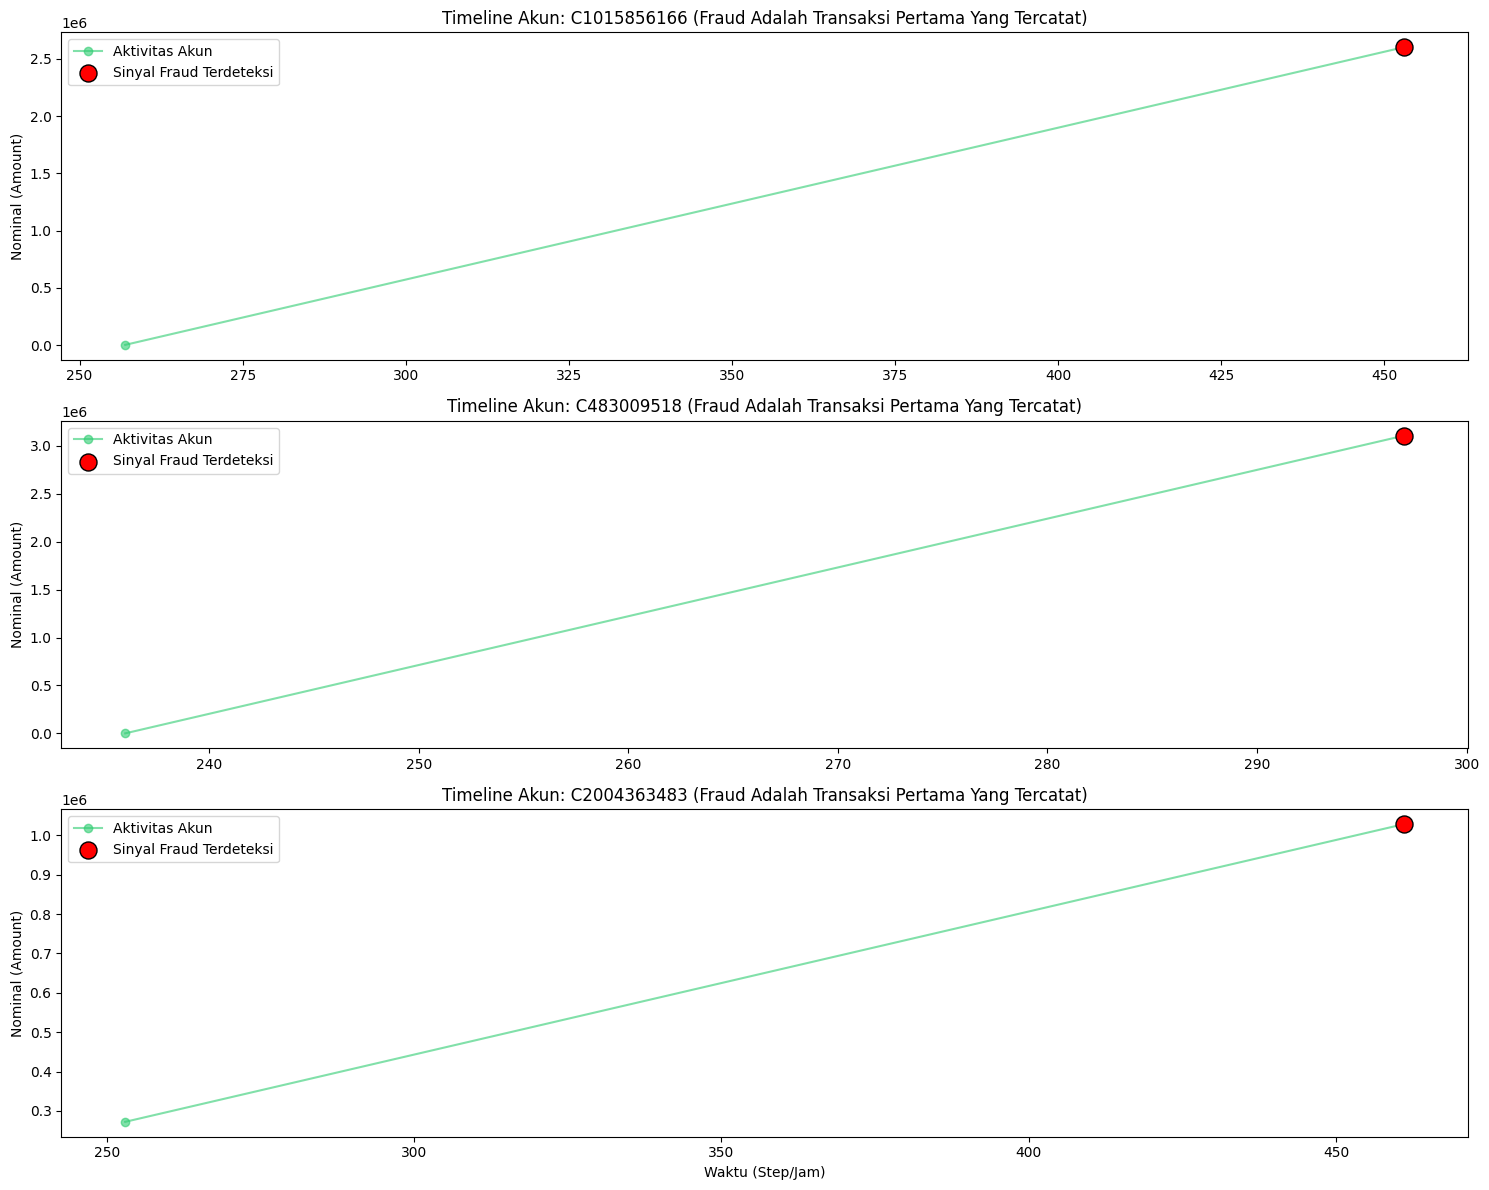

In [45]:
# Mengambil 3 akun contoh
sample_accs = df_fraud_history.groupby('nameOrig').size().sort_values(ascending=False).index[:3]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)

for i, acc in enumerate(sample_accs):
    data = df_fraud_history[df_fraud_history['nameOrig'] == acc].sort_values('step')

    # Plot Garis Nominal Transaksi
    axes[i].plot(data['step'], data['amount'], marker='o', color='#2ecc71', label='Aktivitas Akun', alpha=0.6)

    # Tandai titik Fraud
    fraud_data = data[data['isFraud'] == 1]
    axes[i].scatter(fraud_data['step'], fraud_data['amount'], color='red', s=150,
                    edgecolor='black', label='Sinyal Fraud Terdeteksi', zorder=5)

    axes[i].set_title(f"Timeline Akun: {acc} (Fraud Adalah Transaksi Pertama Yang Tercatat)", fontsize=12)
    axes[i].set_ylabel("Nominal (Amount)")
    axes[i].legend()

plt.xlabel("Waktu (Step/Jam)")
plt.tight_layout()
plt.show()

In [48]:
# Ambil satu akun yang punya sejarah paling lengkap (mendekati 18 transaksi)
best_acc = multi_txn_fraud.groupby('nameOrig').size().idxmax()
acc_data = multi_txn_fraud[multi_txn_fraud['nameOrig'] == best_acc].sort_values('step')

plt.figure(figsize=(15, 6))

# Plot Frekuensi: Hitung selisih waktu antar transaksi (diff step)
acc_data['time_diff'] = acc_data['step'].diff()

# Visualisasi: Semakin kecil 'time_diff', semakin tinggi frekuensinya
plt.plot(acc_data['step'], acc_data['amount'], marker='o', color='#2ecc71', label='Aktivitas Normal', alpha=0.5)

# Highlight 3 transaksi terakhir sebelum Fraud (The Shift Zone)
shift_zone = acc_data.iloc[-4:-1]
plt.scatter(shift_zone['step'], shift_zone['amount'], color='orange', s=200, label='Perubahan Perilaku (Shift)', zorder=4)

# Titik Fraud Akhir
fraud_final = acc_data[acc_data['isFraud'] == 1]
plt.scatter(fraud_final['step'], fraud_final['amount'], color='red', s=300, marker='X', label='Fraud Terdeteksi', zorder=5)

plt.title(f"Bukti Pergeseran Perilaku (Behavioral Shift) pada Akun {best_acc}", fontsize=14)
plt.xlabel("Waktu (Jam/Step)")
plt.ylabel("Nominal Transaksi")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

ValueError: attempt to get argmax of an empty sequence